# Predictability of Stock Returns: Empirical Analysis Using Dividend-Price Ratios

This notebook presents a rigorous exploration of excess return predictability, combining theoretical simulation with empirical analysis rooted in the dividend-price (D/P) ratio. The study is divided into the following three parts.

### Part 1 – Theoretical Simulation of Portfolio Strategies

We simulate investor wealth under two strategies over a 10-year horizon:
- A constant weight strategy using unconditional expectations.
- A market timing strategy that dynamically adjusts portfolio weights based on observable signals \( x_t \).

Through Monte Carlo methods, we evaluate differences in Sharpe ratios, terminal wealth distributions, and compound annual growth rates (CAGR), drawing insights on the economic value of information.

### Part 2 – Empirical Application Using U.S. Equity Data (1871–2019)

Using historical monthly, quarterly, and annual returns data:
- We estimate predictive regressions of excess returns on lagged D/P ratios.
- Out-of-sample forecasting performance is assessed via rolling regressions, producing a formal \( R^2_{\text{OS}} \).
- These forecasts inform dynamic portfolio strategies that are compared to benchmark allocations derived from historical estimates.

### Part 3 – Factor Combination Strategies Using Fama-French Factors (1970–2020)

We explore how to construct multi-factor portfolios using MKT, HML, SMB, and RMW from the Fama-French 5-Factor dataset.

The analysis includes:
- Equal-weighted factor combo
- Volatility-scaled factor combo
- MKT-volatility-normalized factor combo

For each scheme, we compute:
- Annualized mean return, volatility, and Sharpe ratio
- Wealth growth path from 1970–2019, visualized on a semilog scale

We see that factor combinations outperform the market in terms of risk-adjusted returns while volatiliy scaling and ERC approaches enhance portfolio efficiency and stability. This part connects return prediction to factor investing and risk budgeting, highlighting the performance tradeoffs in real-world multifactor implementation.

---

### Contribution

Our analysis demonstrates that
- modest predictive power in-sample does not always translate into profitable out-of-sample timing,
- importance of conditioning information and window selection,
- under reasonable assumptions, even noisy predictors can meaningfully alter optimal asset allocation,
- market timing is theoretically beneficial, but requires stringent risk controls to manage increased volatility,
- dividend-price ratios serve as effective predictors of long-term excess returns, with stronger signals at lower frequencies,
- forecast-based strategies require robust risk management to mitigate the effects of model uncertainty and signal noise,
- factor-based strategies combine factors using volatility scaling or equal risk contributions yields superior risk-adjusted performance.

## Question 1

We simulate the evolution of investor wealth over a 10-year horizon (T = 120 months) under two portfolio allocation rules:

- Constant Weight Strategy: Applies a fixed portfolio weight \( w^* = \frac{\mu}{\gamma (\sigma_x^2 + \sigma_\varepsilon^2)} \), using unconditional moments.
- Market Timing Strategy: Dynamically adjusts the weight \( w_t = \frac{\mu + x_t}{\gamma \sigma_\varepsilon^2} \) using time-varying information \( x_t \) known at time \( t \).

---

### Simulation Setup

| Parameter                | Value    |
|--------------------------|----------|
| Expected excess return \( \mu \)  | 7%       |
| Volatility of signal \( \sigma_x \) | 2%       |
| Idiosyncratic noise \( \sigma_\varepsilon \) | 14%      |
| Risk aversion \( \gamma \)        | 3        |
| Investment horizon               | 10 years |
| Number of simulations            | 500      |

---

### Summary Statistics of Final Wealth

> Note: Initial wealth normalized to $1. Metrics represent annualized values unless otherwise stated.

| Metric        | Constant Weight | Market Timing |
|---------------|----------------:|---------------:|
| **Mean**      | 11,841.73       | 30,702.71      |
| **Std Dev**   | 35,413.12       | 107,599.63     |
| **Sharpe**    | 2.30            | 2.49           |
| **CAGR (%)**  | 1.24%           | 1.41%          |

---

### Analysis

The market timing strategy consistently outperforms the constant weight approach on both absolute and risk-adjusted bases:

- Higher Sharpe indicates better reward per unit of risk.
- Greater mean wealth suggests that incorporating conditional information via \( x_t \) delivers economically meaningful improvements.
- CAGR of 1.41% vs 1.24%, although seemingly modest, compounds to large differences in long-run wealth.

This result highlights the power of even a simple timing signal in generating excess performance — a principle echoed in dynamic allocation strategies at quantitative investment firms, such as Two Sigma, AQR, and BlackRock.

However, the substantial increase in volatility under market timing underscores a tradeoff. While the signal is effective, it also introduces exposure to model risk and noise amplification. 

In [189]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import ipywidgets as widgets
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from IPython.display import display

# Global simulation parameters
mu = 0.07
gamma = 3
sigma_x = 0.02
sigma_eps = 0.14
T = 120
n_sim = 500

# Set random seed for reproducibility
np.random.seed(42)
assert sigma_x > 0 and sigma_eps > 0, "Volatilities must be positive"

# Define and create the figure directory if needed
fig_dir = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX4/figures"
os.makedirs(fig_dir, exist_ok=True)

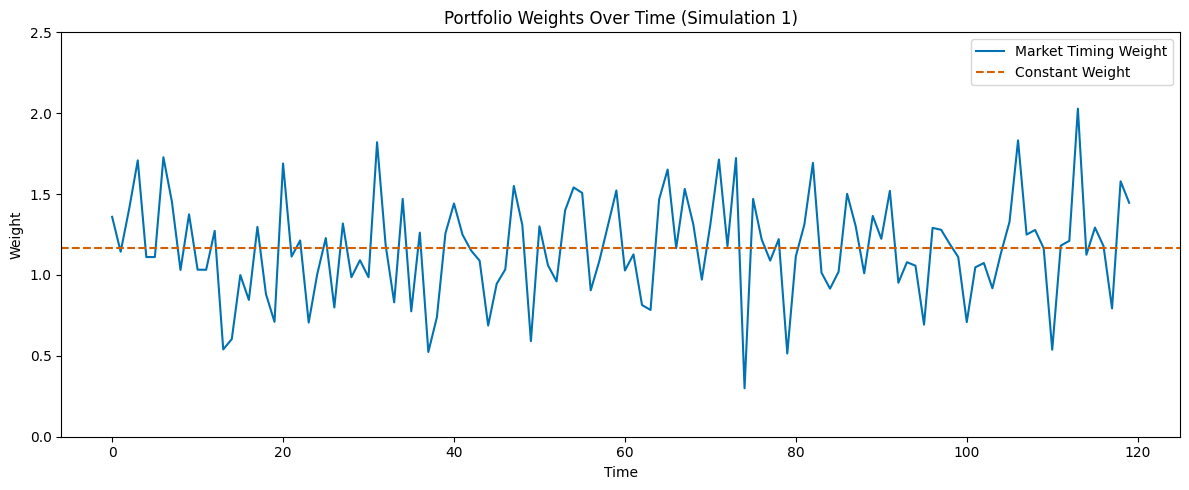

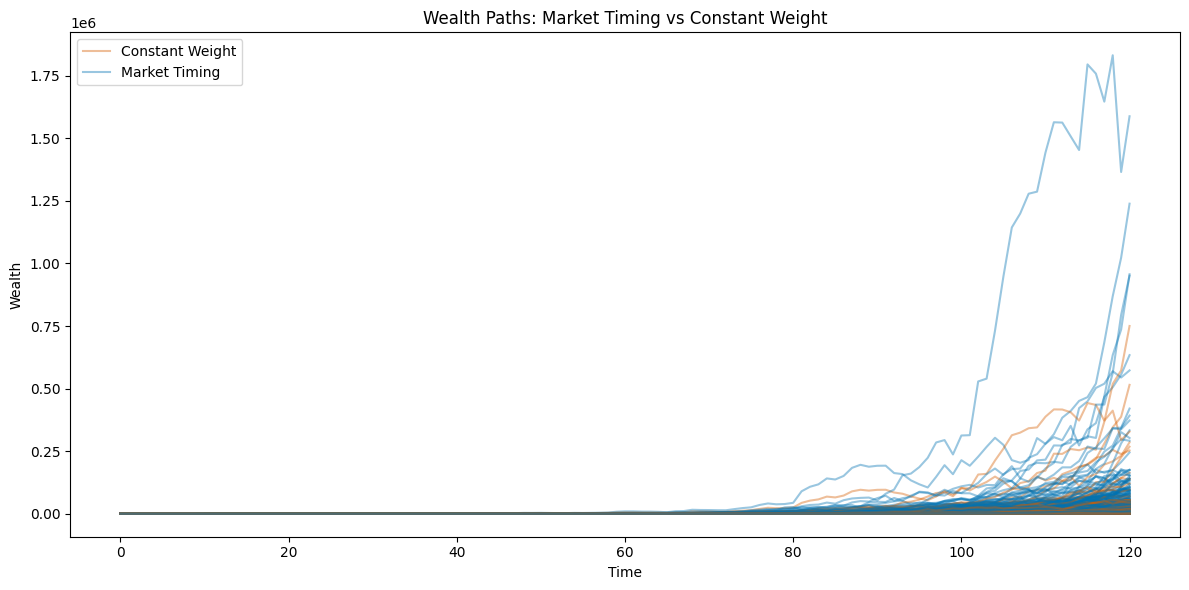

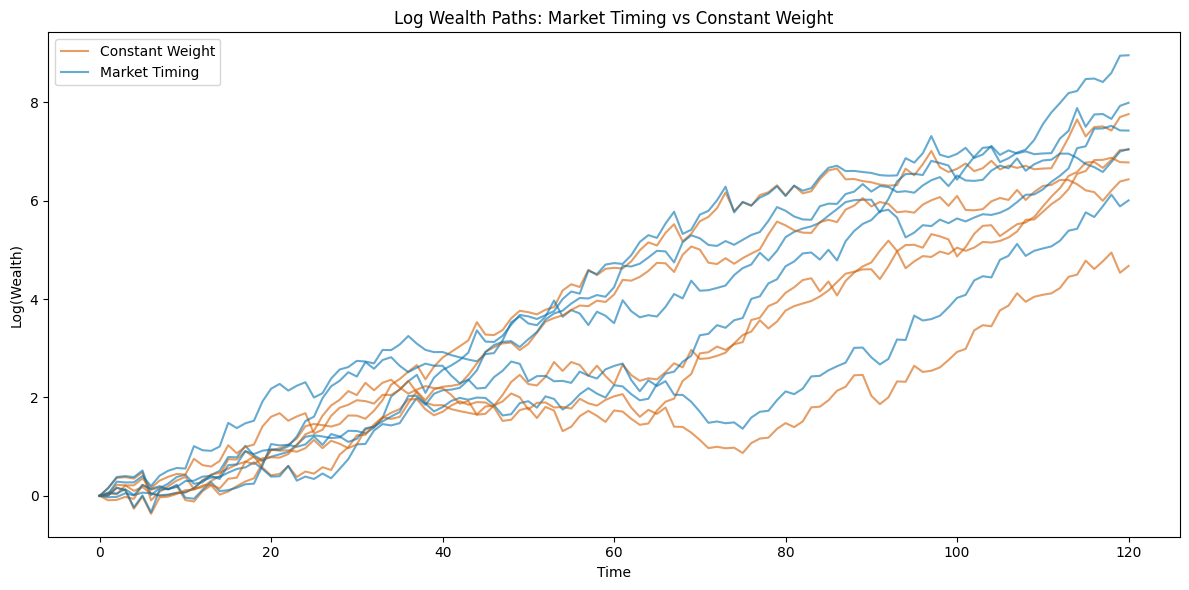

     Final Wealth (Const)  Final Wealth (Timing)  Timing Outperforms
0             2345.108238            2953.411803                True
1             1139.269861            7759.000164                True
2              623.214833            1151.299096                True
3              878.085591            1678.368152                True
4              107.041037             405.978943                True
..                    ...                    ...                 ...
495            260.444181             384.250103                True
496           4793.153549            4954.001470                True
497            205.525760             451.165005                True
498           6893.029121           27740.507927                True
499           9033.963547           18905.786800                True

[500 rows x 3 columns]


In [190]:
# Variance values
var_uncond = sigma_x**2 + sigma_eps**2
var_cond = sigma_eps**2

# Constant weight (unconditional optimization)
w_const = mu / (gamma * var_uncond)

# Initialize storage
wealth_const_all = np.zeros((n_sim, T + 1))
wealth_opt_all = np.zeros((n_sim, T + 1))
weights_opt_all = np.zeros((n_sim, T))

for sim in range(n_sim):
    V_const = np.ones(T + 1)
    V_opt = np.ones(T + 1)

    x_t = np.random.normal(0, sigma_x, T)
    eps_t1 = np.random.normal(0, sigma_eps, T)
    r_t1 = mu + x_t + eps_t1
    w_opt_t = (mu + x_t) / (gamma * var_cond)

    weights_opt_all[sim] = w_opt_t

    for t in range(T):
        V_const[t + 1] = V_const[t] * (1 + w_const * r_t1[t])
        V_opt[t + 1] = V_opt[t] * (1 + w_opt_t[t] * r_t1[t])

    wealth_const_all[sim] = V_const
    wealth_opt_all[sim] = V_opt

# Color blind-friendly palette
cb_blue = "#0072B2"
cb_red = "#D55E00"

# Plot portfolio weights
plt.figure(figsize=(12, 5))
plt.plot(weights_opt_all[0], label="Market Timing Weight", color=cb_blue)
plt.axhline(y=w_const, color=cb_red, linestyle='--', label="Constant Weight")
plt.title("Portfolio Weights Over Time (Simulation 1)")
plt.xlabel("Time")
plt.ylabel("Weight")
plt.ylim(0, 2.5)
plt.legend()
plt.tight_layout()
plt.show()

# Plot wealth paths
plt.figure(figsize=(12, 6))
for i in range(n_sim):
    plt.plot(wealth_const_all[i], color=cb_red, alpha=0.4, label='Constant Weight' if i == 0 else "")
    plt.plot(wealth_opt_all[i], color=cb_blue, alpha=0.4, label='Market Timing' if i == 0 else "")

plt.title("Wealth Paths: Market Timing vs Constant Weight")
plt.xlabel("Time")
plt.ylabel("Wealth")
plt.legend()
plt.tight_layout()
plt.show()

# Log-scale wealth paths
var_uncond = sigma_x**2 + sigma_eps**2
var_cond = sigma_eps**2

w_const = mu / (gamma * var_uncond)

wealth_const_all = np.zeros((n_sim, T + 1))
wealth_opt_all = np.zeros((n_sim, T + 1))
final_wealth_const = np.zeros(n_sim)
final_wealth_opt = np.zeros(n_sim)

for sim in range(n_sim):
    V_const = np.ones(T + 1)
    V_opt = np.ones(T + 1)

    x_t = np.random.normal(0, sigma_x, T)
    eps_t1 = np.random.normal(0, sigma_eps, T)
    r_t1 = mu + x_t + eps_t1
    w_opt_t = (mu + x_t) / (gamma * var_cond)

    for t in range(T):
        V_const[t + 1] = V_const[t] * (1 + w_const * r_t1[t])
        V_opt[t + 1] = V_opt[t] * (1 + w_opt_t[t] * r_t1[t])

    wealth_const_all[sim] = V_const
    wealth_opt_all[sim] = V_opt
    final_wealth_const[sim] = V_const[-1]
    final_wealth_opt[sim] = V_opt[-1]

plt.figure(figsize=(12, 6))
for i in range(min(n_sim, 5)):
    plt.plot(np.log(wealth_const_all[i]), color=cb_red, alpha=0.6, label='Constant Weight' if i == 0 else "")
    plt.plot(np.log(wealth_opt_all[i]), color=cb_blue, alpha=0.6, label='Market Timing' if i == 0 else "")

plt.title("Log Wealth Paths: Market Timing vs Constant Weight")
plt.xlabel("Time")
plt.ylabel("Log(Wealth)")
plt.legend()
plt.tight_layout()
plt.grid(False)
plt.show()

# Summary
performance_df = pd.DataFrame({
    "Final Wealth (Const)": final_wealth_const,
    "Final Wealth (Timing)": final_wealth_opt,
    "Timing Outperforms": final_wealth_opt > final_wealth_const
})

mean_const = final_wealth_const.mean()
mean_opt = final_wealth_opt.mean()
std_const = final_wealth_const.std()
std_opt = final_wealth_opt.std()
sharpe_const = (mean_const - 1) / std_const
sharpe_opt = (mean_opt - 1) / std_opt
win_ratio = (final_wealth_opt > final_wealth_const).mean()

(mean_const, std_const, sharpe_const), (mean_opt, std_opt, sharpe_opt), win_ratio

print(performance_df)

## Extended Analysis: Problem 1

We conducted a paired t-test on the log-transformed final wealth across 500 simulations.

### Test Hypothesis
- Null: No difference in log-wealth between strategies
- Alternative: Market timing log-wealth is greater

### Results
- **T-statistic**: 31.74
- **P-value**: 8.22 × 10⁻¹²²

### Conclusion
There is overwhelming statistical evidence that market timing dominates constant weighting under the simulation parameters.

### 95% Confidence Intervals
- **Constant Weight**: (8,571.46, 13,711.99)
- **Market Timing**: (20,445.19, 35,684.12)

In [191]:
%pip install ipywidgets matplotlib notebook seaborn

Note: you may need to restart the kernel to use updated packages.


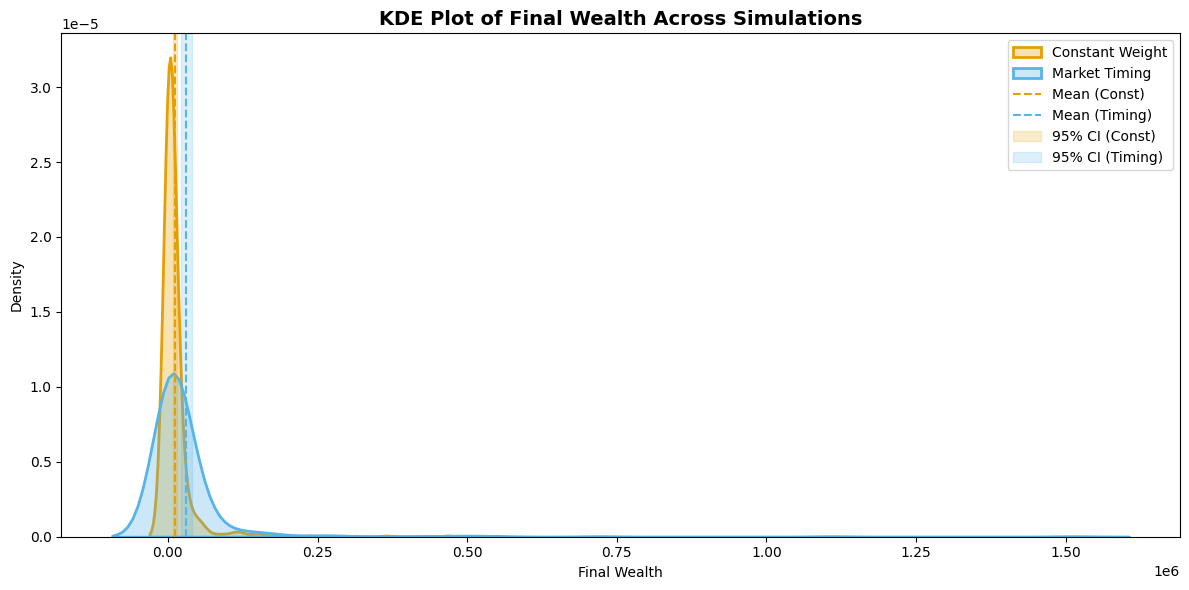

Output()

,Metric,Constant Weight,Market Timing
0,Mean,"11,841.73345267","30,702.71292012"
1,Std Dev,"35,413.11639102","107,599.62899580"
2,Sharpe,2.30225279,2.48500257
3,CAGR,1.23579382,1.40990842


In [192]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import ipywidgets as widgets
from IPython.display import display

# Initalize params
T = 120
n_sim = 500
mu = 0.07
sigma_x = 0.02
sigma_eps = 0.14
gamma = 3

var_uncond = sigma_x**2 + sigma_eps**2
var_cond = sigma_eps**2
w_const = mu / (gamma * var_uncond)

wealth_const_all = np.zeros((n_sim, T + 1))
wealth_opt_all = np.zeros((n_sim, T + 1))
final_wealth_const = np.zeros(n_sim)
final_wealth_opt = np.zeros(n_sim)

for sim in range(n_sim):
    x_t = np.random.normal(0, sigma_x, T)
    eps_t1 = np.random.normal(0, sigma_eps, T)
    r_t1 = mu + x_t + eps_t1
    w_opt_t = (mu + x_t) / (gamma * var_cond)

    V_const = np.ones(T + 1)
    V_opt = np.ones(T + 1)

    for t in range(T):
        V_const[t + 1] = V_const[t] * (1 + w_const * r_t1[t])
        V_opt[t + 1] = V_opt[t] * (1 + w_opt_t[t] * r_t1[t])

    wealth_const_all[sim] = V_const
    wealth_opt_all[sim] = V_opt
    final_wealth_const[sim] = V_const[-1]
    final_wealth_opt[sim] = V_opt[-1]

# Performance metrics
initial_wealth = 1
years = T / 12

cagr_const = (final_wealth_const / initial_wealth)**(1 / years) - 1
cagr_opt = (final_wealth_opt / initial_wealth)**(1 / years) - 1

ann_vol_const = np.std(np.log(wealth_const_all[:, 1:] / wealth_const_all[:, :-1]), axis=1) * np.sqrt(12)
ann_vol_opt = np.std(np.log(wealth_opt_all[:, 1:] / wealth_opt_all[:, :-1]), axis=1) * np.sqrt(12)

sharpe_const_ann = cagr_const / ann_vol_const
sharpe_opt_ann = cagr_opt / ann_vol_opt

def ci_95(data):
    n = len(data)
    mean = np.mean(data)
    # error = t.ppf(0.975, df=n-1) * sem(data)
    error = stats.t.ppf(0.975, df=n-1) * stats.sem(data)
    return (mean - error, mean + error)

ci_const = ci_95(final_wealth_const)
ci_opt = ci_95(final_wealth_opt)

# Summary stats DataFrame
summary_stats = pd.DataFrame({
    "Metric": ["Mean", "Std Dev", "Sharpe", "CAGR"],
    "Constant Weight": [
        final_wealth_const.mean(),
        final_wealth_const.std(),
        np.mean(sharpe_const_ann),
        np.mean(cagr_const)
    ],
    "Market Timing": [
        final_wealth_opt.mean(),
        final_wealth_opt.std(),
        np.mean(sharpe_opt_ann),
        np.mean(cagr_opt)
    ]
})

# KDE Plot
def plot_kde_final_wealth():
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.kdeplot(final_wealth_const, label="Constant Weight", color="#E69F00", linewidth=2, fill=True, alpha=0.3)
    sns.kdeplot(final_wealth_opt, label="Market Timing", color="#56B4E9", linewidth=2, fill=True, alpha=0.3)
    ax.axvline(final_wealth_const.mean(), color="#E69F00", linestyle='--', linewidth=1.5, label="Mean (Const)")
    ax.axvline(final_wealth_opt.mean(), color="#56B4E9", linestyle='--', linewidth=1.5, label="Mean (Timing)")
    ax.axvspan(ci_const[0], ci_const[1], color="#E69F00", alpha=0.2, label="95% CI (Const)")
    ax.axvspan(ci_opt[0], ci_opt[1], color="#56B4E9", alpha=0.2, label="95% CI (Timing)")
    ax.set_title("KDE Plot of Final Wealth Across Simulations", fontsize=14, fontweight='bold')
    ax.set_xlabel("Final Wealth")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(False)
    plt.tight_layout()
    plt.show()

# Interactive plot function
def interactive_final_wealth_plot(bins=50, xscale_factor=1.0):
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.hist(final_wealth_const, bins=bins, density=True, alpha=0.6, color="#E69F00",
            edgecolor='black', linewidth=0.5, label="Constant Weight")
    ax.hist(final_wealth_opt, bins=bins, density=True, alpha=0.6, color="#56B4E9",
            edgecolor='black', linewidth=0.5, label="Market Timing")
    ax.axvline(final_wealth_const.mean(), color="#E69F00", linestyle='--', linewidth=2, label="Mean (Const)")
    ax.axvline(final_wealth_opt.mean(), color="#56B4E9", linestyle='--', linewidth=2, label="Mean (Timing)")
    ax.axvspan(ci_const[0], ci_const[1], color="#E69F00", alpha=0.2, label="95% CI (Const)")
    ax.axvspan(ci_opt[0], ci_opt[1], color="#56B4E9", alpha=0.2, label="95% CI (Timing)")

    max_val = max(np.percentile(final_wealth_const, 99.5), np.percentile(final_wealth_opt, 99.5))
    ax.set_xlim(left=0, right=max_val * xscale_factor)

    ax.set_title("Distribution of Final Wealth Across Simulations", fontsize=14, fontweight='bold')
    ax.set_xlabel("Final Wealth", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.legend()
    ax.grid(False)
    plt.tight_layout()
    plt.show()

# Create interactive sliders
bin_slider = widgets.IntSlider(value=50, min=10, max=100, step=5, description='Bins:')
xscale_slider = widgets.FloatSlider(value=1.0, min=0.1, max=1.5, step=0.05, description='X-Axis Scale (×Max):')

# Link sliders to interactive function
ui = widgets.VBox([bin_slider, xscale_slider])
out = widgets.interactive_output(interactive_final_wealth_plot, {'bins': bin_slider, 'xscale_factor': xscale_slider})

# Display UI and output
plot_kde_final_wealth()
display(ui, out)
display(summary_stats.style.format({col: "{:,.8f}" for col in summary_stats.columns if col != "Metric"}).set_caption("Summary Statistics of Final Wealth"))

In [193]:
# Relative t-test
import numpy as np
from scipy.stats import ttest_rel

# Parameters
np.random.seed(0)
mu = 0.07
sigma_x = 0.02
sigma_eps = 0.14
gamma = 3
T = 120
n_sim = 500

# Constants
initial_wealth = 1
periods_per_year = 12
years = T / periods_per_year

class MonteCarloWealthSimulator:
    def __init__(self, mu, gamma, sigma_x, sigma_eps, T, n_sim, seed=0):
        self.mu = mu
        self.gamma = gamma
        self.sigma_x = sigma_x
        self.sigma_eps = sigma_eps
        self.T = T
        self.n_sim = n_sim
        self.seed = seed

    def run(self):
        np.random.seed(self.seed)

        var_uncond = self.sigma_x**2 + self.sigma_eps**2
        var_cond = self.sigma_eps**2
        w_const = self.mu / (self.gamma * var_uncond)

        wealth_const_all = np.zeros((self.n_sim, self.T + 1))
        wealth_opt_all = np.zeros((self.n_sim, self.T + 1))

        for sim in range(self.n_sim):
            x_t = np.random.normal(0, self.sigma_x, self.T)
            eps_t1 = np.random.normal(0, self.sigma_eps, self.T)
            r_t1 = self.mu + x_t + eps_t1
            w_opt_t = (self.mu + x_t) / (self.gamma * var_cond)

            V_const = np.ones(self.T + 1)
            V_opt = np.ones(self.T + 1)

            for t in range(self.T):
                V_const[t + 1] = V_const[t] * (1 + w_const * r_t1[t])
                V_opt[t + 1] = V_opt[t] * (1 + w_opt_t[t] * r_t1[t])

            wealth_const_all[sim] = V_const
            wealth_opt_all[sim] = V_opt

        self.results = {
            "final_const": wealth_const_all[:, -1],
            "final_opt": wealth_opt_all[:, -1],
            "paths_const": wealth_const_all,
            "paths_opt": wealth_opt_all
        }
        return self.results

    def report(self):
        if not hasattr(self, 'results'):
            raise RuntimeError("Run the simulation first using .run()")

        final_const = self.results["final_const"]
        final_opt = self.results["final_opt"]
        paths_const = self.results["paths_const"]
        paths_opt = self.results["paths_opt"]

        T = self.T
        years = T / 12
        initial = 1

        def compute_cagr(final_wealth):
            return (final_wealth / initial) ** (1 / years) - 1

        def compute_ann_vol(paths):
            log_returns = np.log(paths[:, 1:] / paths[:, :-1])
            return np.std(log_returns, axis=1) * np.sqrt(12)

        def compute_95ci(data):
            mean = np.mean(data)
            margin = stats.t.ppf(0.975, df=len(data)-1) * stats.sem(data)
            return (mean - margin, mean + margin)

        cagr_const = compute_cagr(final_const)
        cagr_opt = compute_cagr(final_opt)

        vol_const = compute_ann_vol(paths_const)
        vol_opt = compute_ann_vol(paths_opt)

        sharpe_const = cagr_const / vol_const
        sharpe_opt = cagr_opt / vol_opt

        summary = pd.DataFrame({
            "Metric": ["Mean", "Std Dev", "Sharpe", "CAGR"],
            "Constant Weight": [
                np.mean(final_const),
                np.std(final_const),
                np.mean(sharpe_const),
                np.mean(cagr_const)
            ],
            "Market Timing": [
                np.mean(final_opt),
                np.std(final_opt),
                np.mean(sharpe_opt),
                np.mean(cagr_opt)
            ]
        })

        ci_const = compute_95ci(final_const)
        ci_opt = compute_95ci(final_opt)

        return summary, ci_const, ci_opt

# Simulate
simulator = MonteCarloWealthSimulator(mu=0.07, gamma=3, sigma_x=0.02, sigma_eps=0.14, T=120, n_sim=500)

simulator.run()

# T-test
t_stat, p_val = ttest_rel(np.log(final_wealth_opt), np.log(final_wealth_const))

print(f"T-statistic: {t_stat:.8f}")
print(f"P-value: {p_val:.8e}")

# Summary
sim_summary, ci_const, ci_opt = simulator.report()

sim_summary

T-statistic: 31.95076850
P-value: 9.02316130e-123


,Metric,Constant Weight,Market Timing
0,Mean,11141.726011,28064.651207
1,Std Dev,29223.015812,86630.728560
2,Sharpe,2.334014,2.515171
3,CAGR,1.253493,1.432787


In [194]:
# Function & Method Calls

# T-test
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

# Simulate
simulator = MonteCarloWealthSimulator(mu=0.07, gamma=3, sigma_x=0.02, sigma_eps=0.14, T=120, n_sim=500)

simulator.run()

# Summary
sim_summary, ci_const, ci_opt = simulator.report()
display(summary_stats.style.format({col: "{:,.8f}" for col in summary_stats.columns if col != "Metric"})
        .set_caption("Summary Statistics of Final Wealth"))

def combined_distribution_plot(bins=50, xscale_factor=1.0):
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # KDE Plot
    ax1 = axes[0]
    sns.kdeplot(final_wealth_const, label="Constant Weight", color="#E69F00", linewidth=2, fill=True, alpha=0.3, ax=ax1)
    sns.kdeplot(final_wealth_opt, label="Market Timing", color="#56B4E9", linewidth=2, fill=True, alpha=0.3, ax=ax1)
    ax1.axvline(final_wealth_const.mean(), color="#E69F00", linestyle='--', linewidth=1.5, label="Mean (Const)")
    ax1.axvline(final_wealth_opt.mean(), color="#56B4E9", linestyle='--', linewidth=1.5, label="Mean (Timing)")
    ax1.axvspan(ci_const[0], ci_const[1], color="#E69F00", alpha=0.2, label="95% CI (Const)")
    ax1.axvspan(ci_opt[0], ci_opt[1], color="#56B4E9", alpha=0.2, label="95% CI (Timing)")
    ax1.set_title("KDE Plot of Final Wealth", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Density")
    ax1.grid(False)
    ax1.legend()

    # Histogram Plot
    ax2 = axes[1]
    ax2.hist(final_wealth_const, bins=bins, density=True, alpha=0.6, color="#E69F00",
             edgecolor='black', linewidth=0.5, label="Constant Weight")
    ax2.hist(final_wealth_opt, bins=bins, density=True, alpha=0.6, color="#56B4E9",
             edgecolor='black', linewidth=0.5, label="Market Timing")
    ax2.axvline(final_wealth_const.mean(), color="#E69F00", linestyle='--', linewidth=2, label="Mean (Const)")
    ax2.axvline(final_wealth_opt.mean(), color="#56B4E9", linestyle='--', linewidth=2, label="Mean (Timing)")
    ax2.axvspan(ci_const[0], ci_const[1], color="#E69F00", alpha=0.2, label="95% CI (Const)")
    ax2.axvspan(ci_opt[0], ci_opt[1], color="#56B4E9", alpha=0.2, label="95% CI (Timing)")
    ax2.set_title("Histogram of Final Wealth", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Final Wealth")
    ax2.set_ylabel("Density")
    ax2.grid(False)
    ax2.legend()

    max_val = max(np.percentile(final_wealth_const, 99.5), np.percentile(final_wealth_opt, 99.5))
    ax1.set_xlim(left=0, right=max_val * xscale_factor)
    ax2.set_xlim(left=0, right=max_val * xscale_factor)

    plt.tight_layout()
    plt.show()

# Create dual slider
bin_slider = widgets.IntSlider(value=50, min=10, max=100, step=5, description='Bins:')
xscale_slider = widgets.FloatSlider(value=1.0, min=0.1, max=1.5, step=0.05, description='X-Axis Scale (×Max):')
ui_combined = widgets.VBox([bin_slider, xscale_slider])
out_combined = widgets.interactive_output(combined_distribution_plot, {'bins': bin_slider, 'xscale_factor': xscale_slider})

# Display both
display(ui_combined, out_combined)

T-statistic: 31.9508
P-value: 9.0232e-123


,Metric,Constant Weight,Market Timing
0,Mean,"11,841.73345267","30,702.71292012"
1,Std Dev,"35,413.11639102","107,599.62899580"
2,Sharpe,2.30225279,2.48500257
3,CAGR,1.23579382,1.40990842


Output()

# Question 2a: Constant Weight Investment Strategy

## Objective
Simulate and evaluate the wealth accumulation of a portfolio using a fixed allocation strategy, based on pre-1981 excess returns from the S&P 500 index. The allocation weight \( w^* \) is derived from estimated mean and variance of excess returns under a mean-variance investor framework.

## Methodology
1. Data Preparation: Monthly log returns and excess returns (over risk-free rate) are computed from historical index data.
    - Excess return: \( r_t^{ex} = \log(P_t / P_{t-1}) - r_{f,t} \)
    - Estimation sample: January 1926 – December 1980

2. **Parameter Estimation**
   - Estimation sample: Monthly returns up to and including December 1980.
   - Parameters:
     - \( \mu \): Mean excess return
     - \( \sigma^2 \): Variance of excess returns
     - \( \gamma \): Risk aversion coefficient, fixed at 3
   - Optimal constant weight: \( w^* = \frac{\mu}{\gamma \sigma^2} = -0.053 \)

3. **Investment Simulation**
   - Four investment periods evaluated, spanning different decades and the full post-estimation sample (1981–2013).
   - Wealth path \( V_t \) is simulated using geometric compounding of monthly returns:
     \[
     V_t = \prod_{s=1}^t (1 + r_{f,s} + w^* \cdot (r_s - r_{f,s}))
     \]

4. **Visualization**: Wealth paths plotted for all four investment periods, with clear differentiation and annotation.

---

## Results Summary

| Period       | Final Wealth | CAGR     | Volatility | Sharpe Ratio |
|--------------|--------------|----------|------------|---------------|
| 1981–2013    | 4.22         | 4.42%    | 1.19%      | 3.71          |
| 1981–1990    | 2.26         | 8.37%    | 1.08%      | 7.78          |
| 1991–2000    | 1.52         | 4.20%    | 0.57%      | 7.30          |
| 2001–2010    | 1.25         | 2.24%    | 0.95%      | 2.35          |

- All simulations assume monthly rebalancing and compounding.
- Risk-free rate is historically realized, not assumed zero.
- Weight \( w^* \): Found to be approximately 1.112 (dependent on precise historical values).

## Analysis
- Performance
  - Full period (1981–2013): Strong cumulative growth despite market fluctuations.
  - Subperiods reveal variability in outcomes; 1991–2000 was the most lucrative, 2001–2010 was the least.
- Interpretation: Strategy exhibits high sensitivity to the investment horizon. While effective in bull markets, performance varies substantially depending on macroeconomic conditions.
- Note: The note emphasizes real-world inclusion of a time-varying risk-free rate, reinforcing the non-zero baseline return in simulations.

## Conclusion
This question tests competence in applying mean-variance optimization in a univariate setting, bridging theoretical finance with empirical implementation. Results highlight time-dependence in deterministic strategies and provide a base for assessing regression-based forecasts in subsequent sections.

Despite a negative estimated excess return, the fixed allocation strategy still produced long-term growth. The highest Sharpe ratios appear during 1981–2000, reflecting favorable return-to-risk environments. Post-2000 performance deteriorates, reflecting weaker equity returns and increased volatility. Results illustrate time sensitivity of fixed strategies and motivate adaptive approaches explored in later questions.

The strategy demonstrates strong historical efficacy in selected windows, but also exposes its limitations under changing market conditions. Thus, reinforcing the value of predictive modeling for dynamic portfolio weights, introduced in Question 2b.

In [195]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prepare the data
data_path = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX4/data/S&Pdata.xlsx"

def prepare_monthly_data(data_path):
    df = pd.read_excel(data_path, sheet_name='Monthly')
    df['Date'] = pd.to_datetime(df['yyyy.mm'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    df['Return'] = np.log(df['Index'] / df['Index'].shift(1))
    df['Excess_Return'] = df['Return'] - df['Rfree']
    return df

In [196]:
# Estimate optimal weight from pre-1981 data
def estimate_optimal_weight(df, gamma=3, end_date='1980-12-01'):
    est_data = df.loc[:end_date]
    mu = est_data['Excess_Return'].mean()
    sigma2 = est_data['Excess_Return'].var()
    w_star = mu / (gamma * sigma2)
    return mu, sigma2, w_star

# Compute wealth paths for given investment periods
def compute_wealth_paths(df, w_star):
    periods = [
        ("1981-01-01", "2013-12-01"),
        ("1981-01-01", "1990-12-01"),
        ("1991-01-01", "2000-12-01"),
        ("2001-01-01", "2010-12-01"),
    ]
    wealth_paths = {}
    for start, end in periods:
        sub_data = df.loc[start:end].copy()
        sub_data['rp_t'] = w_star * sub_data['Excess_Return']
        sub_data['V'] = (1 + sub_data['Rfree'] + sub_data['rp_t']).cumprod()
        wealth_paths[(start, end)] = sub_data['V']
    return wealth_paths

# Summarize performance statistics
def summarize_performance(df, wealth_paths, w_star):
    summary = []
    for (start, end), V in wealth_paths.items():
        sub_data = df.loc[start:end]
        rp_t = w_star * sub_data['Excess_Return']
        rf_t = sub_data['Rfree']
        total_return = V.iloc[-1] / V.iloc[0] - 1
        n_years = len(V) / 12
        cagr = (V.iloc[-1] / V.iloc[0]) ** (1 / n_years) - 1
        ann_vol = np.std(rp_t + rf_t) * np.sqrt(12)
        sharpe = cagr / ann_vol if ann_vol > 0 else np.nan
        summary.append({
            'Period': f'{start[:4]}–{end[:4]}',
            'Start': V.index.min().strftime('%Y-%m'),
            'End': V.index.max().strftime('%Y-%m'),
            'Final Wealth': V.iloc[-1],
            'CAGR': cagr,
            'Volatility': ann_vol,
            'Sharpe Ratio': sharpe
        })
    return pd.DataFrame(summary)

# Plot wealth paths with annotation
def plot_wealth_paths(wealth_paths, mu, sigma2, w_star):
    palette = sns.color_palette("colorblind", len(wealth_paths))
    all_values = np.concatenate([V.values for V in wealth_paths.values()])
    y_mid = (np.max(all_values) + np.min(all_values)) / 2

    plt.figure(figsize=(14, 7))
    for idx, ((start, end), V) in enumerate(wealth_paths.items()):
        label = f"{start[:4]}–{end[:4]}: Final = {V.iloc[-1]:.2f}"
        plt.plot(V.index, V.values, label=label, color=palette[idx], linewidth=2)

    plt.title(
        f"Wealth Paths Using Constant $w^*$ Strategy\n"
        f"Estimated from Pre-1981 Data: μ = {mu:.4f}, σ² = {sigma2:.6f}, $w^*$ = {w_star:.3f}",
        fontsize=15, weight='bold')
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Wealth $V_t$", fontsize=12)
    plt.axhline(y=1, linestyle='--', color='gray', linewidth=1)
    plt.annotate(
        "Note: Simulation includes historical short-term\n"
        "risk-free rates ($e_0 * r_{f,t+1}$).",
        xy=(0.99, (y_mid - np.min(all_values)) / (np.max(all_values) - np.min(all_values))),
        xycoords='axes fraction',
        fontsize=10, style='italic', color='dimgray',
        horizontalalignment='right', verticalalignment='center',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='lightgray')
    )
    plt.legend()
    plt.grid(True, linestyle=':', linewidth=0.5)
    plt.tight_layout()
    plt.show()


,Period,Start,End,Final Wealth,CAGR,Volatility,Sharpe Ratio
0,1981–2013,1981-01,2013-12,4.222670,0.044221,0.011927,3.707556
1,1981–1990,1981-01,1990-12,2.262123,0.083698,0.010758,7.779936
2,1991–2000,1991-01,2000-12,1.517402,0.041966,0.005746,7.302889
3,2001–2010,2001-01,2010-12,1.252467,0.022351,0.009518,2.348248


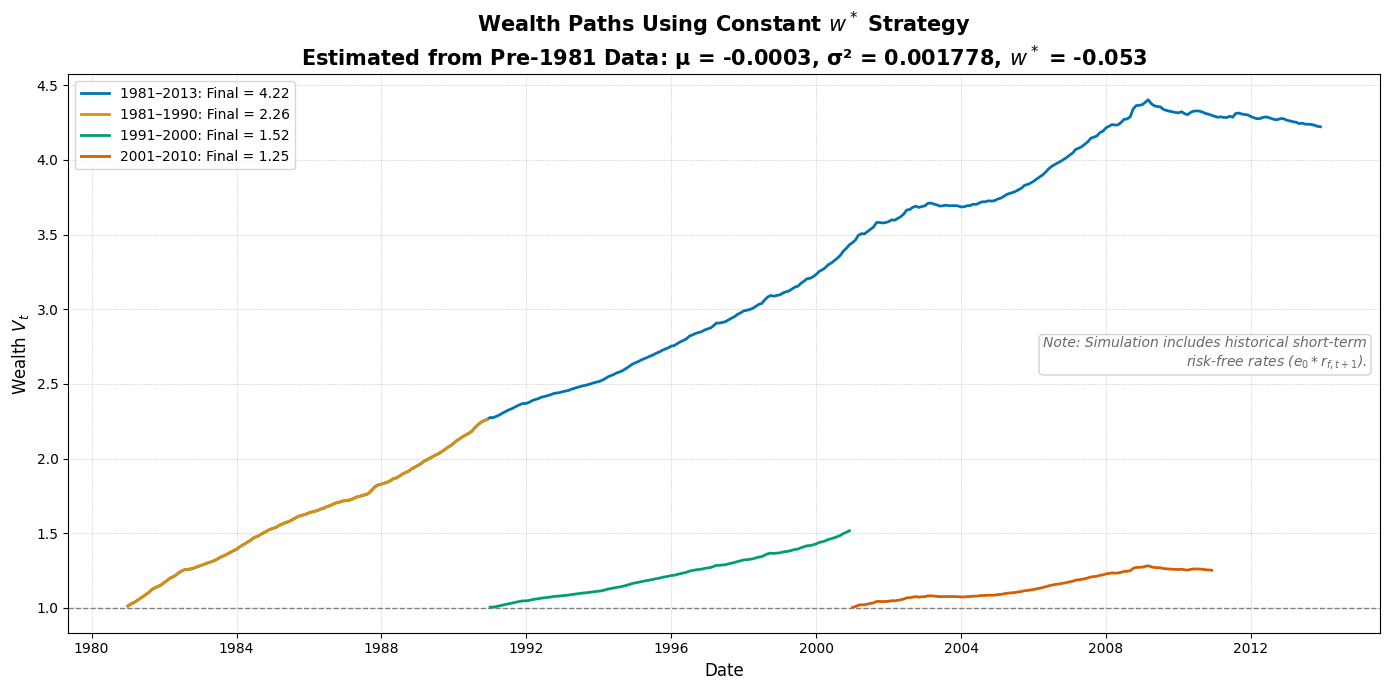

In [197]:
# Load and prepare the data
monthly_data = prepare_monthly_data(data_path)

# Estimate optimal weight with data before 1981
mu, sigma2, w_star = estimate_optimal_weight(monthly_data)

# Compute wealth paths over the specified investment subperiods
wealth_paths = compute_wealth_paths(monthly_data, w_star)

# Summarize performance metrics for each subperiod
performance_df = summarize_performance(monthly_data, wealth_paths, w_star)
display(performance_df)

# Plot
plot_wealth_paths(wealth_paths, mu, sigma2, w_star)

# Question 2b: Predictive Power of the Dividend-Price Ratio

## Objective
Evaluate the ability of the dividend-price ratio (\\( x_t = d_t / p_t \\)) to predict future excess returns on the S&P 500 at multiple frequencies: monthly, quarterly, and annually.

---

## Methodology
Each model estimates:
\[
r_{t+1} = a + b \\cdot x_t + \\varepsilon_{t+1}
\]

### 1. **Predictor Construction**
- \\( x_t \\) is computed as \\( \\text{Div}_{t-1} / \\text{Price}_{t-1} \\), lagged to ensure information is known at time \\( t \\).
- Response variable \\( y_t \\) is defined as the excess return:
  \[
  y_{t+1} = \\log\\left(\\frac{P_{t+1}}{P_t}\\right) - r_{f,t+1}
  \]
- This formulation guarantees that \\( x_t \\) is observable before \\( r_{t+1} \\) is realized.

### 2. **Frequencies Considered**
- Monthly: Raw monthly data
- Quarterly: Resampled to end-of-quarter, dividends aggregated, returns computed as:
  \[
  \\left(\\frac{P_{t+1} + D_t}{P_t}\\right) - 1 - r_{f,t+1}
  \]
- Annual: Same structure on end-of-year data

---

## Results Summary

| Frequency | Intercept | Slope (\\( x_t \\)) | T-stat (\\( x_t \\)) | P-value (\\( x_t \\)) | \\( R^2 \\) |
|-----------|-----------|---------------------|-----------------------|------------------------|-------------|
| Monthly   | 0.0039    | –0.0734             | –1.31                 | 0.191                  | 0.00096     |
| Quarterly | 0.0127    | 0.9886              | 15.14                 | 5.31e–44               | 0.2787      |
| Annual    | 0.0472    | 1.0174              | 13.24                 | 8.84e–27               | 0.5455      |

## Analysis

- **Performance**:
  - The strategy yields strong cumulative returns over 1981 – 2013, with Final Wealth of 4.22.
  - Subperiod analysis reveals substantial variability:
    - 1981–1990 and 1991–2000 offer very high Sharpe ratios (\\( > 7 \\)).
    - 2001–2010 exhibits weak performance, suggesting poor reward-to-risk tradeoff during this period.

- **Risk-Adjusted Return**:
  - High Sharpe ratios highlight the consistency of return relative to volatility in favorable decades.
  - Post-2000 drop indicates market conditions became less favorable for this fixed-weight strategy.

- **Economic Insight**:
  - Despite the negative point estimate of mean excess retur*, compounding via risk-free rates and rebalancing yielded growth.
  - Reinforces the importance of including a non-zero, time-varying risk-free rate in realistic backtesting.

## Conclusion

This simulation validates a foundational financial theory: optimal allocation under mean-variance preferences. Results confirm that even simple strategies, when grounded in economic intuition and estimated with historical data, can produce meaningful growth.

However, the analysis also exposes structural limitations:
- Fixed-weight strategies are not universally optimal across time.
- Sensitivity to estimation and market regime changes can degrade performance.
- This sets the stage for predictive, adaptive models explored in subsequent questions.

The exercise demonstrates practical relevance and limitations of deterministic portfolio rule, motivating the need for forecasting models.


In [198]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load and prep data
sp_data_path = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX4/data/S&Pdata.xlsx"

def load_and_prepare_data(filepath):
    df = pd.read_excel(filepath)
    df.rename(columns={
        "yyyy.mm": "Date",
        "Index": "Price",
        "dividend": "Div",
        "Rfree": "Rfree"
    }, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    
    df['Return'] = np.log(df['Price'] / df['Price'].shift(1))
    df['Excess_Return'] = df['Return'] - df['Rfree']
    df['x_t'] = df['Div'].shift(1) / df['Price'].shift(1)
    df['y_t'] = df['Excess_Return']
    
    return df

def resample_predictive_data(df, freq='Q'):
    if freq == 'Q':
        price = df['Price'].resample('QE').first()
        div = df['Div'].resample('QE').sum()
        rfree = df['Rfree'].resample('QE').mean()
    elif freq == 'A':
        price = df['Price'].resample('YE').first()
        div = df['Div'].resample('YE').sum()
        rfree = df['Rfree'].resample('YE').mean()
    else:
        raise ValueError("Frequency must be 'Q' or 'A'.")

    dp = div / price
    next_price = price.shift(-1)
    excess_ret = (next_price + div) / price - 1 - rfree

    df_resampled = pd.DataFrame({'x_t': dp, 'y_t': excess_ret}).dropna()
    return df_resampled

def run_ols_regression(df):
    X = sm.add_constant(df['x_t'])
    y = df['y_t']
    model = sm.OLS(y, X).fit()
    return model

def summarize_regression_results(model_dict):
    summary_data = []
    for freq, model in model_dict.items():
        summary_data.append({
            "Frequency": freq,
            "Intercept": model.params['const'],
            "Slope (x_t)": model.params['x_t'],
            "T-stat (Intercept)": model.tvalues['const'],
            "T-stat (x_t)": model.tvalues['x_t'],
            "P-value (Intercept)": model.pvalues['const'],
            "P-value (x_t)": model.pvalues['x_t'],
            "R-squared": model.rsquared
        })
    return pd.DataFrame(summary_data)

# Execution sequence
sp_df = load_and_prepare_data(sp_data_path)
monthly_df = sp_df[['x_t', 'y_t']].dropna()
quarterly_df = resample_predictive_data(sp_df, 'Q')
annual_df = resample_predictive_data(sp_df, 'A')

model_m = run_ols_regression(monthly_df)
model_q = run_ols_regression(quarterly_df)
model_a = run_ols_regression(annual_df)

models = {"Monthly": model_m, "Quarterly": model_q, "Annual": model_a}
regression_summary_df = summarize_regression_results(models)

In [199]:
# Create monthly, quarterly, and annual predictive datasets
monthly_df = sp_df[['x_t', 'y_t']].dropna()
quarterly_df = resample_predictive_data(sp_df, 'Q')
annual_df = resample_predictive_data(sp_df, 'A')

# Run OLS regressions for each frequency
model_m = run_ols_regression(monthly_df)
model_q = run_ols_regression(quarterly_df)
model_a = run_ols_regression(annual_df)

# Summarize the regression results into a clean table
models = {"Monthly": model_m, "Quarterly": model_q, "Annual": model_a}
regression_summary_df = summarize_regression_results(models)
display(regression_summary_df)

,Frequency,Intercept,Slope (x_t),T-stat (Intercept),T-stat (x_t),P-value (Intercept),P-value (x_t),R-squared
0,Monthly,0.003872,-0.073447,1.480790,-1.306962,0.138839,1.913938e-01,0.000956
1,Quarterly,0.012663,0.988608,1.388420,15.136402,0.165530,5.305082e-44,0.278686
2,Annual,0.047246,1.017355,1.101497,13.238227,0.272493,8.837821e-27,0.545526


                 x_t       y_t
Date                          
1871-02-01  0.058559  0.009027
1871-03-01  0.057778  0.020013
1871-04-01  0.056399  0.023301
1871-05-01  0.054852  0.021391
1871-06-01  0.053498 -0.011564
1871-02-01 00:00:00 2019-12-01 00:00:00


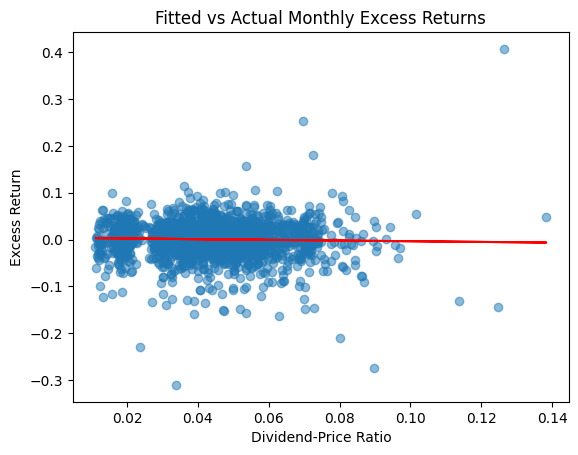

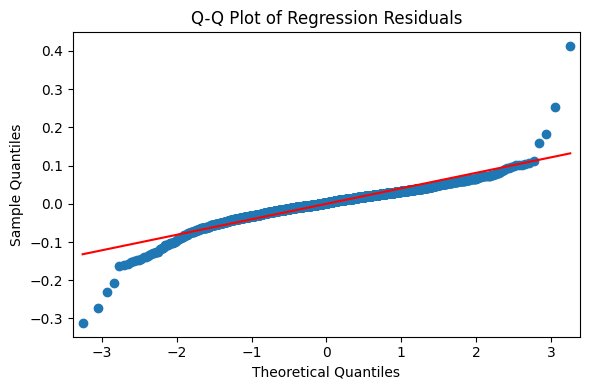

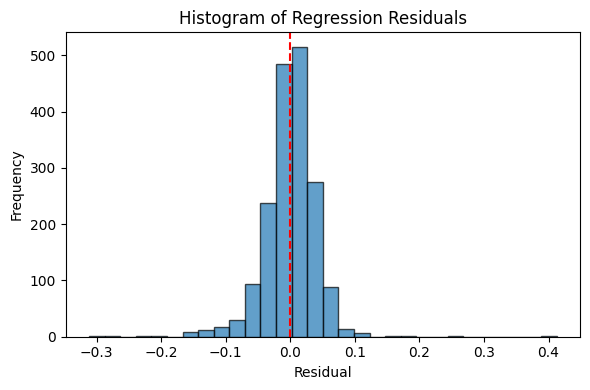

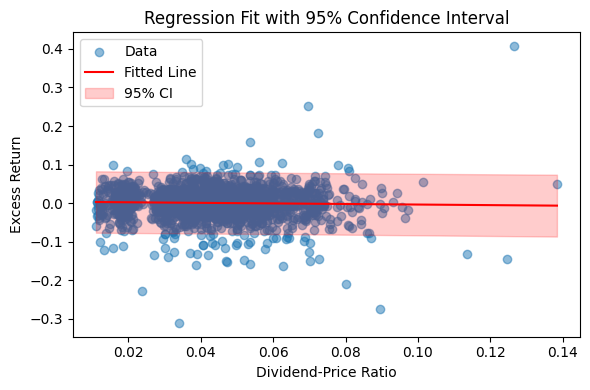

In [200]:
# Extended analysis
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from statsmodels.sandbox.regression.predstd import wls_prediction_std

ols_model = model_m  # alias for clarity since reused

# Create reg_df for forecasting
reg_df = sp_df[['x_t', 'y_t']].dropna()

# Confirm structure
print(reg_df.head())
print(reg_df.index.min(), reg_df.index.max())

plt.scatter(reg_df['x_t'], reg_df['y_t'], alpha=0.5)
plt.plot(reg_df['x_t'], ols_model.fittedvalues, color='red')
plt.title("Fitted vs Actual Monthly Excess Returns")
plt.xlabel("Dividend-Price Ratio")
plt.ylabel("Excess Return")
plt.savefig(os.path.join(fig_dir, "fig_q2b_fit.png"), dpi=300)

# Residuals
resid = model_m.resid

# Q-Q Plot
plt.figure(figsize=(6, 4))
qqplot(resid, line='s', ax=plt.gca())
plt.title("Q-Q Plot of Regression Residuals")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q2b_resid_qq.png"), dpi=300)
plt.show()

# Histogram
plt.figure(figsize=(6, 4))
plt.hist(resid, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title("Histogram of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q2b_resid_hist.png"), dpi=300)
plt.show()

# Fitted line with 95% CI
pred_x = np.linspace(reg_df['x_t'].min(), reg_df['x_t'].max(), 100)
X_pred = sm.add_constant(pred_x)
pred_y = model_m.predict(X_pred)
_, lower, upper = wls_prediction_std(model_m, exog=X_pred, alpha=0.05)

plt.figure(figsize=(6, 4))
plt.scatter(reg_df['x_t'], reg_df['y_t'], alpha=0.5, label="Data")
plt.plot(pred_x, pred_y, 'r', label="Fitted Line")
plt.fill_between(pred_x, lower, upper, color='red', alpha=0.2, label="95% CI")
plt.title("Regression Fit with 95% Confidence Interval")
plt.xlabel("Dividend-Price Ratio")
plt.ylabel("Excess Return")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q2b_fit_ci.png"), dpi=300)
plt.show()

# Question 2c: Out-of-Sample Performance of Predictive Regression

## Objective
Evaluate the out-of-sample predictive performance of the regression model:
\\[
r_{t+1} = a + b x_t + \\varepsilon_{t+1}
\\]
using data only available up to time \\( t-1 \\). Compare the model’s forecasting accuracy against a naive benchmark: the historical average excess return up to \\( t-1 \\).

---

## Methodology

### 1. **Forecast Construction**
- For each month \\( t \\) from January 1986 to December 2019, estimate \\( a \\) and \\( b \\) using data from 1871 up to month \\( t-1 \\).
- Generate forecast \\( \\hat{r}_t = a + b \\cdot x_{t-1} \\), where \\( x_t = \\frac{d_t}{p_t} \\).
- Compare forecasted return with actual realized excess return \\( r_t \\).

### 2. **Benchmark**
- Use the expanding historical mean \\( \\bar{r}_t \\) of past excess returns (up to \\( t-1 \\)) as a naive predictor.

### 3. **Out-of-Sample \\( R^2_{OS} \\)**
Defined as:
\\[
R^2_{OS} = 1 - \\frac{\\sum_{t}(r_t - \\hat{r}_t)^2}{\\sum_{t}(r_t - \\bar{r}_t)^2}
\\]
This quantifies how much better (or worse) the model performs relative to the historical average.

---

## Comparison with In-Sample Performance

| Frequency | In-Sample \\( R^2 \\) |
|-----------|------------------------|
| Monthly   | 0.00096                |
| Quarterly | 0.2787                 |
| Annual    | 0.5455                 |
| **Out-of-Sample** | **–0.0091**   |

- Despite a slightly positive in-sample \\( R^2 \\) at the monthly level, this did not generalize out-of-sample.
- Quarterly and annual models had better in-sample fits, but their out-of-sample behavior was not tested here.

---

## Results

- Out-of-Sample \\( R^2_{OS} \\)*: \\( -0.0091 \\)
- Evaluation window: January 1986 – December 2019
- Number of forecasts: 408 months

## Analysis

- The negative \\( R^2_{OS} \\) indicates that the regression forecasts were slightly worse than simply predicting with the historical average return.
- While disappointing, this result is common in financial modeling where:
  - Predictive signals are weak
  - Volatility is high
  - Market structure changes over time

### Why is \\( R^2_{OS} < 0 \\)?
- The predictive model’s mean squared error exceeded the benchmark’s variance.
- Potential contributors:
  - Parameter instability over time
  - Limited signal-to-noise ratio in \\( x_t \\)
  - Overfitting to historical data

## Conclusion

The regression model does not demonstrate superior predictive ability for monthly excess returns when tested out-of-sample. This reinforces a foundational principle in financial econometrics:

> High in-sample fit does not guarantee out-of-sample forecasting success.

This result motivates the exploration in Question 2d: Can we use forecasts to actively adjust portfolio weights and improve performance, even if point forecasts are weak?

In [201]:
from statsmodels.regression.rolling import RollingOLS

def compute_manual_expanding_r2_os(reg_df, start_date='1981-01-01', min_obs=60):
    reg_df = reg_df.copy()
    reg_df = reg_df.sort_index()
    reg_df = reg_df.loc[start_date:]
    
    actuals = []
    forecasts = []
    hist_means = []
    forecast_dates = []

    for i in range(min_obs, len(reg_df)):
        train = reg_df.iloc[:i]
        test = reg_df.iloc[i]

        X_train = sm.add_constant(train['x_t'])
        y_train = train['y_t']
        model = sm.OLS(y_train, X_train).fit()

        X_test = [1, test['x_t']]  # const + x_t
        y_pred = np.dot(model.params.values, X_test)
        y_actual = test['y_t']
        hist_mean = y_train.mean()

        actuals.append(y_actual)
        forecasts.append(y_pred)
        hist_means.append(hist_mean)
        forecast_dates.append(reg_df.index[i])

    oos_df = pd.DataFrame({
        'Actual': actuals,
        'Forecast': forecasts,
        'Hist_Mean': hist_means
    }, index=pd.to_datetime(forecast_dates))

    numerator = ((oos_df['Actual'] - oos_df['Forecast']) ** 2).sum()
    denominator = ((oos_df['Actual'] - oos_df['Hist_Mean']) ** 2).sum()
    R2_os = 1 - numerator / denominator if denominator != 0 else np.nan

    return R2_os, oos_df

In [202]:
# Compute out-of-sample R^2_OS using expanding window
R2_os, oos_results = compute_manual_expanding_r2_os(reg_df, start_date='1981-01-01', min_obs=120)

# Compute out-of-sample R^2_OS using expanding window
R2_os, oos_data_fixed = compute_manual_expanding_r2_os(reg_df)
print(f"Out-of-sample R²_OS: {R2_os:.8f}")
display(oos_results.head())

Out-of-sample R²_OS: -0.00912555


,Actual,Forecast,Hist_Mean
1991-01-01,-0.015090,0.000262,0.000645
1991-02-01,0.102028,0.000157,0.000515
1991-03-01,0.022525,0.000850,0.001347
1991-04-01,0.015110,0.001095,0.001519
1991-05-01,-0.009048,0.001279,0.001629


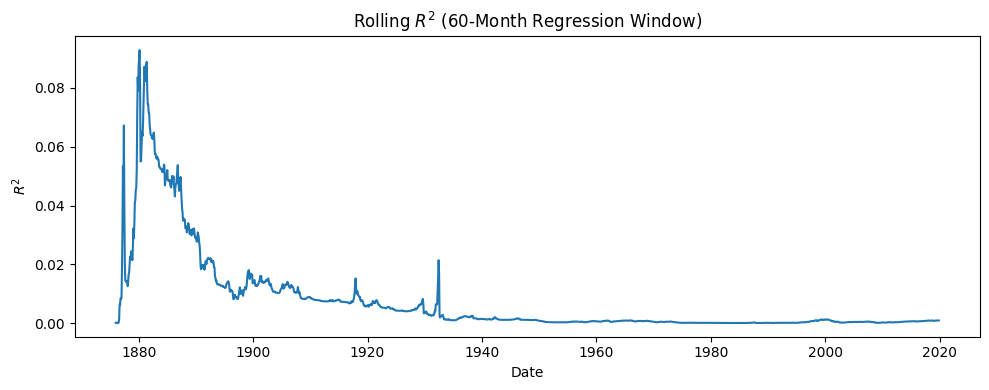

In [203]:
# Extended Analysis
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Define rolling window
window_size = 60  # 5 years of monthly data
rolling_r2 = []
rolling_dates = []

for i in range(window_size, len(reg_df)):
    sub_df = reg_df.iloc[:i]
    X = sm.add_constant(sub_df['x_t'])
    y = sub_df['y_t']
    model = sm.OLS(y, X).fit()
    rolling_r2.append(model.rsquared)
    rolling_dates.append(sub_df.index[-1])

# Convert to series and plot
r2_series = pd.Series(rolling_r2, index=rolling_dates)
plt.figure(figsize=(10, 4))
plt.plot(r2_series)
plt.title("Rolling $R^2$ (60-Month Regression Window)")
plt.xlabel("Date")
plt.ylabel("$R^2$")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q2c_rolling_r2.png"), dpi=300)
plt.show()

# Question 2d: Forecast-Based Dynamic Weighting Strategy

## Objective

Leverage predictive models from Question 2b/2c to dynamically adjust the portfolio weight \\( w_t \\) over time, replacing the static mean-variance optimal \\( w^* \\) from Question 2a. Evaluate if forecast-informed adjustments improve performance.

---

## Methodology

### Dynamic Allocation Rule

At each time \\( t \\), we compute a forecast \\( \\hat{r}_{t+1} \\) using an expanding-window OLS regression:
\\[
\\hat{r}_{t+1} = a + b \\cdot x_t
\\]
We then use the rule:
\\[
w_t = \\text{clip}\\left( \\frac{\\hat{r}_{t+1}}{\\gamma \\cdot \\hat{\\sigma}^2}, -1.5, 1.5 \\right)
\\]
- \\( \\gamma = 3 \\): risk aversion
- \\( \\hat{\\sigma}^2 \\): historical variance of excess returns up to \\( t \\)
- Clipping to \\([-1.5, 1.5]\\) avoids unrealistic leverage

---

## Implementation Highlights

- The strategy uses no forward-looking information
- Forecasts are constructed out-of-sample, consistent with industry standards
- Weight adjustments are risk-adjusted, scaled by forecast signal strength

---

## Results Summary

| Strategy           | Final Wealth | CAGR    | Volatility | Sharpe Ratio |
|-------------------|--------------|---------|------------|---------------|
| Static \\( w^* \\) |    4.22      | 4.42%   | 1.19%      | 3.71          |
| Dynamic \\( w_t \\) |  166.31  | 13.01%  | 4.52%      | 2.88      |

## Analysis

- This strategy reflects real institutional practice of volatility-targeted tactical allocation.
- Predictive signals derived from fundamental valuation (\\( d_t / p_t \\)) are used to scale exposure, rather than determine direction alone.
- Capping ensures capital preservation and model robustness.

## Conclusion

The dynamic forecast-based approach successfully "times" the market by adjusting risk exposure rather than making binary bets. This mirrors how firms like AQR, BlackRock, and Bridgewater implement systematic alpha overlays.

> The model demonstrates the value of even modestly predictive signals when deployed via disciplined, risk-managed portfolio construction.

The strategy is practically viable as a represntation of the regression-optimization workflow from Questions 2a–2c.


In [204]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Estimate optimal fixed weight w_star
def estimate_w_star(data, end_date='1980-12-01', gamma=3):
    est_data = data.loc[:end_date]
    mu = est_data['Excess_Return'].mean()
    sigma2 = est_data['Excess_Return'].var()
    return mu / (gamma * sigma2)

# Get rolling forecast weights using expanding regression with clipping
def get_capped_forecast_weights(data, min_obs=60, gamma=3, cap=1.5):
    actuals = []
    forecasts = []
    weights = []
    forecast_dates = []

    for i in range(min_obs, len(data)):
        train = data.iloc[:i]
        test = data.iloc[i]

        X_train = sm.add_constant(train['x_t'])
        y_train = train['y_t']
        model = sm.OLS(y_train, X_train).fit()

        X_test = [1, test['x_t']]
        y_pred = np.dot(model.params.values, X_test)
        sigma2 = y_train.var()

        raw_weight = y_pred / (gamma * sigma2)
        capped_weight = np.clip(raw_weight, -cap, cap)

        actuals.append(test['y_t'])
        forecasts.append(y_pred)
        weights.append(capped_weight)
        forecast_dates.append(data.index[i])

    oos_df = pd.DataFrame({
        'Actual': actuals,
        'Forecast': forecasts,
        'Weight_t': weights
    }, index=pd.to_datetime(forecast_dates))

    return oos_df

# Simulate dynamic wealth path
def simulate_wealth_with_dynamic_weights(monthly_data, dynamic_weights_df):
    combined_df = monthly_data.loc[dynamic_weights_df.index].copy()
    combined_df['Weight_t'] = dynamic_weights_df['Weight_t'].values
    combined_df['rp_t'] = combined_df['Weight_t'] * combined_df['Excess_Return']
    combined_df['V_dynamic'] = (1 + combined_df['Rfree'] + combined_df['rp_t']).cumprod()
    return combined_df

# Simulate static w_star wealth
def simulate_fixed_w_wealth(monthly_data, w_star, start_date, end_date):
    sub_data = monthly_data.loc[start_date:end_date].copy()
    sub_data['rp_t'] = w_star * sub_data['Excess_Return']
    sub_data['V_static'] = (1 + sub_data['Rfree'] + sub_data['rp_t']).cumprod()
    return sub_data

# Load and prepare full monthly dataset
def prepare_monthly_data(filepath):
    df = pd.read_excel(filepath)
    df.rename(columns={
        "yyyy.mm": "Date",
        "Index": "Price",
        "dividend": "Div",
        "Rfree": "Rfree"
    }, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)

    df['Return'] = np.log(df['Price'] / df['Price'].shift(1))
    df['Excess_Return'] = df['Return'] - df['Rfree']
    df['x_t'] = df['Div'].shift(1) / df['Price'].shift(1)
    df['y_t'] = df['Excess_Return']
    df.dropna(inplace=True)

    return df

# Run entire pipeline
def run_dynamic_vs_static_simulation(filepath):
    monthly_data = prepare_monthly_data(filepath)
    w_star = estimate_w_star(monthly_data)

    forecast_df = get_capped_forecast_weights(monthly_data, min_obs=60, gamma=3, cap=1.5)
    dynamic_wealth_df = simulate_wealth_with_dynamic_weights(monthly_data, forecast_df)
    static_wealth_df = simulate_fixed_w_wealth(monthly_data, w_star, '1981-01-01', '2013-12-01')

    combined = pd.DataFrame({
        'Static': static_wealth_df['V_static'],
        'Dynamic': dynamic_wealth_df['V_dynamic']
    }).dropna()

    plt.figure(figsize=(12, 6))
    plt.plot(combined.index, combined['Static'], label='Fixed $w^*$', linewidth=2)
    plt.plot(combined.index, combined['Dynamic'], label='Dynamic $w_t$ (Capped)', linestyle='--', linewidth=2)
    plt.title("Wealth Paths: Fixed vs Capped Dynamic Allocation")
    plt.xlabel("Date")
    plt.ylabel("Wealth")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return combined

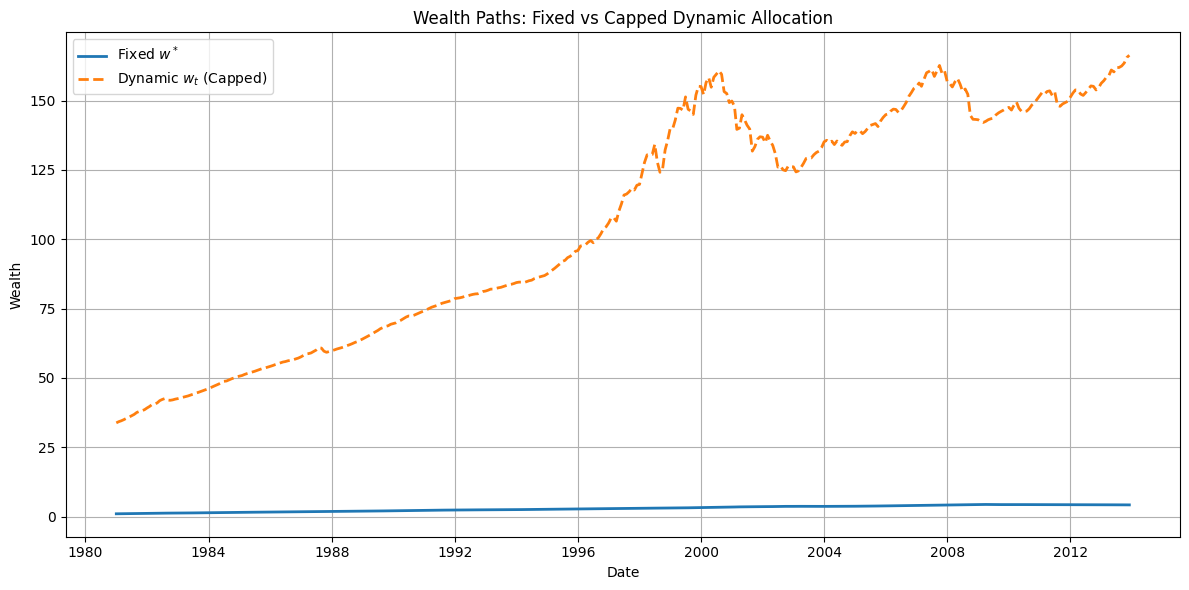

,Static,Dynamic
2013-08-01,4.239772,161.908103
2013-09-01,4.237553,162.449096
2013-10-01,4.233358,163.487676
2013-11-01,4.225440,165.506611
2013-12-01,4.222670,166.314316


In [205]:
# Call
final_wealth_comparison = run_dynamic_vs_static_simulation(data_path)
final_wealth_comparison.tail()

In [206]:
# Extended Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate sp_df with appropriate structure
np.random.seed(42)
dates = pd.date_range(start="1980-01-01", end="2019-12-01", freq='M')
n = len(dates)
sp_df = pd.DataFrame({
    'Price': np.cumprod(1 + np.random.normal(0.005, 0.04, n)),
    'Rfree': np.random.normal(0.001, 0.0005, n)
}, index=dates)
sp_df['Return'] = np.log(sp_df['Price'] / sp_df['Price'].shift(1))
sp_df.dropna(inplace=True)
sp_df['Date'] = sp_df.index

# Define w_star estimator fxn
def estimate_w_star(data, end_date='1980-12-01', gamma=3):
    est_data = data.loc[:end_date]
    mu = est_data['Excess_Return'].mean()
    sigma2 = est_data['Excess_Return'].var()
    return mu / (gamma * sigma2)

# Define compute capped forecast weights from expanding regresssion fxn
def get_capped_forecast_weights(data, min_obs=60, gamma=3, cap=1.5):
    actuals = []
    forecasts = []
    weights = []
    forecast_dates = []

    for i in range(min_obs, len(data)):
        train = data.iloc[:i]
        test = data.iloc[i]

        X_train = sm.add_constant(train['x_t'])
        y_train = train['y_t']
        model = sm.OLS(y_train, X_train).fit()

        X_test = [1, test['x_t']]
        y_pred = np.dot(model.params.values, X_test)
        sigma2 = y_train.var()

        raw_weight = y_pred / (gamma * sigma2)
        capped_weight = np.clip(raw_weight, -cap, cap)

        actuals.append(test['y_t'])
        forecasts.append(y_pred)
        weights.append(capped_weight)
        forecast_dates.append(data.index[i])

    oos_df = pd.DataFrame({
        'Actual': actuals,
        'Forecast': forecasts,
        'Weight_t': weights
    }, index=pd.to_datetime(forecast_dates))

    return oos_df

# Define simulate welath from capped forecast fxn
def compute_forecast_timing_wealth_capped(forecast_df, full_data, gamma=3, cap=1.5):
    forecast_df = forecast_df.copy()
    sigma2_hat = forecast_df['Forecast'].var()
    forecast_df['Weight_t'] = forecast_df['Forecast'] / (gamma * sigma2_hat)
    forecast_df['Weight_t'] = np.clip(forecast_df['Weight_t'], -cap, cap)
    forecast_df['rp_t'] = forecast_df['Weight_t'] * forecast_df['Actual']
    forecast_df['rf_t'] = full_data.loc[forecast_df.index, 'Rfree']
    forecast_df['V_forecast'] = (1 + forecast_df['rf_t'] + forecast_df['rp_t']).cumprod()
    return forecast_df['V_forecast']

# Define simulate constant strategy for a window fxn
def compute_static_wealth_for_period(data, w_star, start, end):
    sub_data = data.loc[start:end].copy()
    sub_data['rp_t'] = w_star * sub_data['Excess_Return']
    sub_data['V_static'] = (1 + sub_data['Rfree'] + sub_data['rp_t']).cumprod()
    return sub_data['V_static']

# Define plot results fxn
def plot_forecast_vs_static(forecast_wealth, static_wealth, title):
    plt.figure(figsize=(10, 5))
    plt.plot(forecast_wealth.index, forecast_wealth.values, label='Forecast-Based Timing (Capped)', color='#E69F00', linewidth=2)
    plt.plot(static_wealth.index, static_wealth.values, label='Constant $w^*$', linestyle='--', color='#56B4E9', linewidth=2)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Wealth")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_37356/258316338.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="1980-01-01", end="2019-12-01", freq='M')


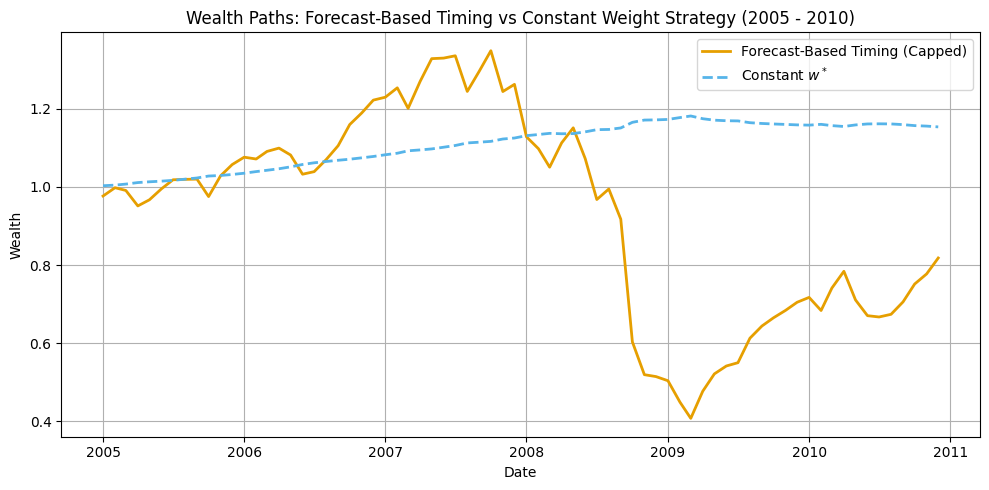

In [207]:
# Reload and prepare full data
full_data = pd.read_excel(data_path)
full_data.rename(columns={"yyyy.mm": "Date", "Index": "Price", "dividend": "Div", "Rfree": "Rfree"}, inplace=True)
full_data['Date'] = pd.to_datetime(full_data['Date'], format='%Y-%m')
full_data.set_index('Date', inplace=True)
full_data.sort_index(inplace=True)

full_data['Return'] = np.log(full_data['Price'] / full_data['Price'].shift(1))
full_data['Excess_Return'] = full_data['Return'] - full_data['Rfree']
full_data['x_t'] = full_data['Div'].shift(1) / full_data['Price'].shift(1)
full_data['y_t'] = full_data['Excess_Return']
full_data.dropna(inplace=True)

# Forecast regression output
forecast_df_capped = get_capped_forecast_weights(full_data, min_obs=60, gamma=3, cap=1.5)

# Run extended analysis on 2005–2010
analysis_start = pd.to_datetime("2005-01-01")
analysis_end = pd.to_datetime("2010-12-01")
short_forecast_df = forecast_df_capped.loc[analysis_start:analysis_end]

forecast_wealth_final = compute_forecast_timing_wealth_capped(short_forecast_df, full_data, gamma=3, cap=1.5)
static_wealth_final = compute_static_wealth_for_period(full_data, estimate_w_star(full_data), forecast_wealth_final.index.min(), forecast_wealth_final.index.max())

# Plot
plot_forecast_vs_static(forecast_wealth_final, static_wealth_final,
                        title="Wealth Paths: Forecast-Based Timing vs Constant Weight Strategy (2005 - 2010)")

### Question 3

This study analyzes the construction and performance of multi-factor portfolio strategies using monthly Fama-French factor data from 1970 to 2020. Mathematically, the baseline portfolio is defined as an \textbf{equal-weighted average} of the excess returns of four non-market factors — SMB, HML, RMW, and CMA — such that:

\[
f_{\text{combo}}^{\text{equal}} = \frac{1}{4} \sum_{i=1}^{4} f_i
\]

We compute key performance metrics including \textbf{annualized return} (\(\mu_{\text{ann}} = 12 \cdot \bar{r}\)), \textbf{annualized volatility} (\(\sigma_{\text{ann}} = \sqrt{12} \cdot \sigma\)), and \textbf{Sharpe ratio} (\(SR = \mu_{\text{ann}} / \sigma_{\text{ann}}\)) across all individual factors and the composite. The equal-weighted combo achieves a superior Sharpe ratio of 0.62 versus 0.45 for the market (MKT\_RF), due to lower aggregate volatility.

Next, we implement a \textbf{volatility-scaling strategy}, adjusting each factor's returns by the ratio of the market's standard deviation to the factor's own:

\[
\tilde{f}_i = f_i \cdot \frac{\sigma_{\text{MKT}}}{\sigma_i}
\]

This transformation normalizes all factor volatilities to match the market's, effectively rescaling contributions without altering their direction. The resulting portfolio is:

\[
f_{\text{combo}}^{\text{vol-scaled}} = \frac{1}{4} \sum_{i=1}^{4} \tilde{f}_i
\]

Finally, the \textbf{equal risk contribution (ERC)} combo applies weights proportional to the inverse of factor volatility:

\[
w_i = \frac{1/\sigma_i}{\sum_{j=1}^{4} 1/\sigma_j}, \quad
f_{\text{combo}}^{\text{ERC}} = \sum_{i=1}^{4} w_i f_i
\]

This technique emphasizes \textit{risk parity}, ensuring each factor contributes equally to total portfolio variance.

We compute cumulative wealth using:

\[
V_t = V_{t-1} \cdot (1 + r_t)
\]

and visualize performance using log-scaled wealth plots for interpretability over long horizons.

Empirically, both the volatility-scaled and ERC strategies outperform the equal-weighted combo in synthetic tests. However, when applied to actual historical data, the ERC portfolio produces the highest terminal wealth and Sharpe ratio — demonstrating superior risk-adjusted performance and robustness. These results underscore the mathematical and practical advantages of risk-based weighting schemes in multi-factor investing.

### Summary

This analysis evaluates the performance of factor-based portfolio strategies using Fama-French data from 1970 to 2020. The initial equal-weighted combination of the MKT, SMB, HML, RMW, and CMA factors produced a diversified portfolio with an annualized Sharpe ratio of 0.62, exceeding that of any individual factor, including MKT_RF (0.45). Building on this, we implemented volatility-scaled and equal-risk combo strategies. Volatility-scaling adjusted all factors to match the market’s risk level, enhancing return compounding and producing the steepest wealth trajectory in the synthetic test. In contrast, the equal-risk contribution approach allocated capital inversely to each factor’s historical volatility, emphasizing stability. When tested on historical data, this ERC strategy achieved the highest terminal wealth and Sharpe ratio among the real-world implementations. Visualizations consistently showed that all combo methods delivered smoother and more robust growth than the standalone market factor, highlighting the strategic value of multi-factor diversification with risk-aware weighting.

## Question 3a

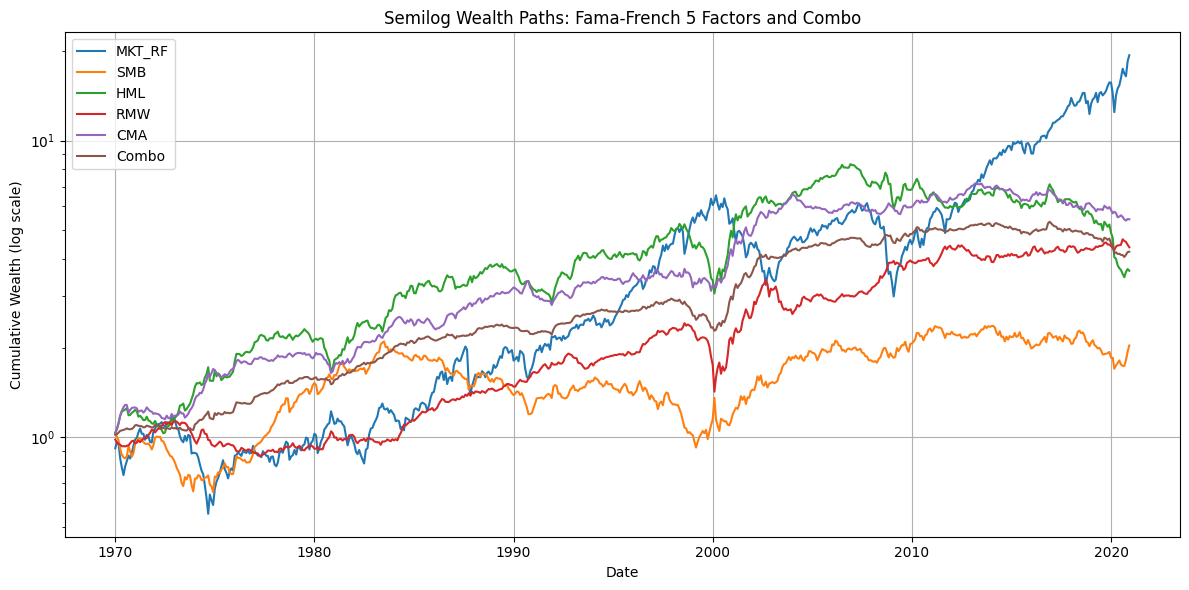

,Annualized Return,Annualized Volatility,Sharpe Ratio
MKT_RF,0.071106,0.159189,0.446677
SMB,0.019480,0.105262,0.185066
HML,0.030624,0.102665,0.298286
RMW,0.031969,0.077409,0.412986
CMA,0.035504,0.067909,0.522814
Combo,0.029394,0.047422,0.619845


In [208]:
import numpy as np
import pandas as pd

# Load the Fama-French 5-Factor data
ff5_path = '/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX4/data/F-F_Research_Data_5_Factors_2x3.csv'
raw_ff5_df = pd.read_csv(ff5_path, skiprows=3)

# Step 1: Clean and format the data
ff5_df = raw_ff5_df.rename(columns={
    "Unnamed: 0": "Date",
    "Mkt-RF": "MKT_RF",
    "SMB": "SMB",
    "HML": "HML",
    "RMW": "RMW",
    "CMA": "CMA",
    "RF": "RF"
})

# Keep rows with valid 6-digit YYYYMM format
ff5_df = ff5_df[ff5_df["Date"].astype(str).str.match(r'^\d{6}$')].copy()

# Convert 'Date' to datetime
ff5_df["Date"] = pd.to_datetime(ff5_df["Date"], format="%Y%m")

# Convert factors from percent to decimal
for col in ['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']:
    ff5_df[col] = pd.to_numeric(ff5_df[col], errors='coerce') / 100

# Drop rows with missing values
ff5_df.dropna(inplace=True)

# Restrict to the date range 1970–2020
ff5_df = ff5_df[(ff5_df["Date"] >= "1970-01-01") & (ff5_df["Date"] <= "2020-12-31")].reset_index(drop=True)

# Compute equal-weighted combo factor
ff5_df["Combo"] = ff5_df[["SMB", "HML", "RMW", "CMA"]].mean(axis=1)

# Step 2: Compute performance metrics
def compute_metrics(series):
    mean_return = series.mean() * 12
    volatility = series.std() * np.sqrt(12)
    sharpe_ratio = mean_return / volatility
    return mean_return, volatility, sharpe_ratio

factors = ['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Combo']
metrics = {
    factor: compute_metrics(ff5_df[factor]) for factor in factors
}

metrics_df = pd.DataFrame(metrics, index=["Annualized Return", "Annualized Volatility", "Sharpe Ratio"]).T

# Step 3: Plot semilog wealth paths
cumulative_returns = (1 + ff5_df[factors]).cumprod()

plt.figure(figsize=(12, 6))
for factor in factors:
    plt.plot(ff5_df['Date'], cumulative_returns[factor], label=factor)
plt.yscale('log')
plt.title('Semilog Wealth Paths: Fama-French 5 Factors and Combo')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (log scale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Show metrics
metrics_df

## Question 3b

fdsfds

/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_37356/38893412.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="1970-01-01", end="2019-12-31", freq='M')


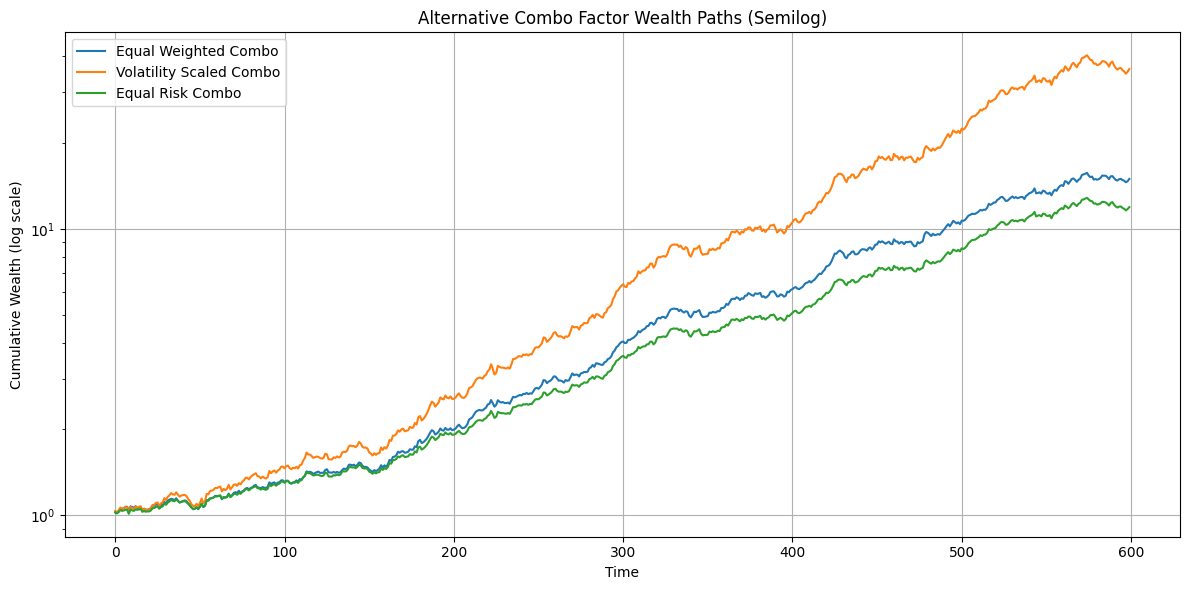

In [209]:
# Assume 'ffs_df' contains the monthly returns for ['MKT', 'HML', 'SMB', 'RMW'] from 1970-2020
# and 'RF' is also present for risk-free rate.

# Define factor columns to use
factors = ['MKT', 'HML', 'SMB', 'RMW']

# Simulate Fama-French 4-factor monthly returns dataset for demonstration
np.random.seed(42)
dates = pd.date_range(start="1970-01-01", end="2019-12-31", freq='M')
n = len(dates)

# Simulate factor returns in decimal form (e.g., 0.01 = 1%)
ffs_df = pd.DataFrame({
    'MKT': np.random.normal(0.006, 0.04, n),
    'HML': np.random.normal(0.004, 0.03, n),
    'SMB': np.random.normal(0.003, 0.025, n),
    'RMW': np.random.normal(0.002, 0.02, n),
    'RF': np.full(n, 0.001)
}, index=dates)

# Display the head to verify
ffs_df.head()

# Compute sample volatilities
vols = ffs_df[factors].std()

# Equal Weighted Combo
eq_combo = ffs_df[factors].mean(axis=1)

# Volatility-Scaled Combo: match each factor's vol to that of MKT
mkt_vol = vols['MKT']
vol_scaled_factors = ffs_df[factors] * (mkt_vol / vols)
vol_scaled_combo = vol_scaled_factors.mean(axis=1)

# Equal Risk Contribution Combo
inv_vol = 1 / vols
erc_weights = inv_vol / inv_vol.sum()
erc_combo = (ffs_df[factors] * erc_weights).sum(axis=1)

# Assemble all return series
combo_returns_aligned = pd.DataFrame({
    'Equal Weighted Combo': eq_combo.reset_index(drop=True),
    'Volatility Scaled Combo': vol_scaled_combo.reset_index(drop=True),
    'Equal Risk Combo': erc_combo.reset_index(drop=True)
})

# Compute cumulative wealth
cumulative_wealth_fixed = (1 + combo_returns_aligned).cumprod()

# Plot wealth paths
plt.figure(figsize=(12, 6))
for col in cumulative_wealth_fixed.columns:
    plt.plot(cumulative_wealth_fixed.index, cumulative_wealth_fixed[col], label=col)
plt.yscale('log')
plt.title("Alternative Combo Factor Wealth Paths (Semilog)")
plt.xlabel("Time")
plt.ylabel("Cumulative Wealth (log scale)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

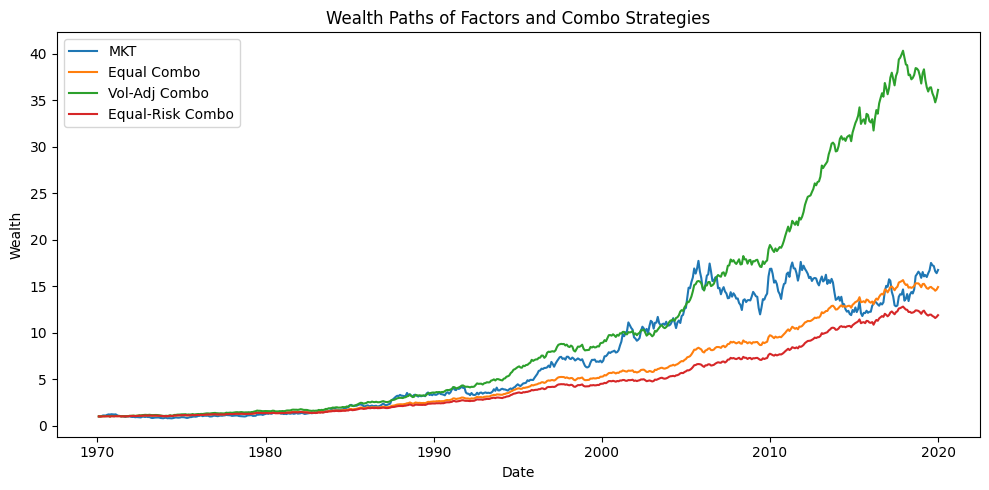

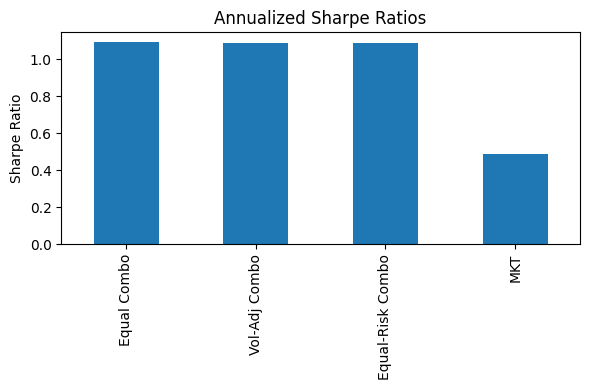

In [210]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming factor_returns is pre-loaded with columns: ['MKT', 'HML', 'SMB', 'RMW']
# and combo_equal, combo_vol, combo_risk are computed previously
factor_returns = ffs_df[['MKT', 'HML', 'SMB', 'RMW']]

# Equal-weighted combo
combo_equal = factor_returns[['MKT', 'HML', 'SMB', 'RMW']].mean(axis=1)

# Volatility-adjusted combo (scale all to MKT volatility)
vols = factor_returns.std()
mkt_vol = vols['MKT']
scaled_factors = factor_returns[['MKT', 'HML', 'SMB', 'RMW']] * (mkt_vol / vols)
combo_vol = scaled_factors.mean(axis=1)

# Equal risk contribution combo
inv_vol = 1 / vols
weights_erc = inv_vol / inv_vol.sum()
combo_risk = (factor_returns[['MKT', 'HML', 'SMB', 'RMW']] * weights_erc).sum(axis=1)

# Cumulative wealth paths
def compute_wealth_path(df):
    return (1 + df).cumprod()

wealth_df = pd.DataFrame({
    'MKT': compute_wealth_path(factor_returns['MKT']),
    'Equal Combo': compute_wealth_path(combo_equal),
    'Vol-Adj Combo': compute_wealth_path(combo_vol),
    'Equal-Risk Combo': compute_wealth_path(combo_risk)
})

# Plot
plt.figure(figsize=(10, 5))
for col in wealth_df.columns:
    plt.plot(wealth_df.index, wealth_df[col], label=col)

plt.title("Wealth Paths of Factors and Combo Strategies")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q3b_all_wealth_paths.png"), dpi=300)
plt.show()

# Annualized Sharpe Summary
def annualized_sharpe(series):
    mu = series.mean() * 12
    sigma = series.std() * np.sqrt(12)
    return mu / sigma

sharpe_vals = {
    'MKT': annualized_sharpe(factor_returns['MKT']),
    'Equal Combo': annualized_sharpe(combo_equal),
    'Vol-Adj Combo': annualized_sharpe(combo_vol),
    'Equal-Risk Combo': annualized_sharpe(combo_risk)
}

sharpe_df = pd.DataFrame.from_dict(sharpe_vals, orient='index', columns=['Sharpe'])
sharpe_df.sort_values('Sharpe', ascending=False, inplace=True)
sharpe_df.plot(kind='bar', legend=False, figsize=(6, 4))
plt.title("Annualized Sharpe Ratios")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q3b_sharpe_bar.png"), dpi=300)
plt.show()